In [1]:
# ============================================================
# CELL 0: SETUP — MOUNT DRIVE, IMPORTS, OUTPUT PATH
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results'
results_output_dir = os.path.join(OUTPUT_DIR, 'final_comparison')
os.makedirs(results_output_dir, exist_ok=True)

print(f'Output directory ready: {results_output_dir}')

Mounted at /content/drive
Output directory ready: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison


In [2]:
# ============================================================
# CELL 1: FINAL RESULTS TABLE (all numbers hardcoded manually)
# ============================================================
final_results = {
    'Frozen ME5-Large (fused text)':            {'success@1': 0.1924, 'success@5': 0.5113, 'success@10': 0.6139},
    'Fine-tuned ME5-Large + LoRA (fused text)':  {'success@1': 0.2260, 'success@5': 0.5840, 'success@10': 0.6891},
}

results_df = pd.DataFrame(final_results).T[['success@1', 'success@5', 'success@10']]
results_df.index.name = 'Model'

print('=== Hindi→English Crosslingual Retrieval — Final Test Results ===\n')
print(results_df.round(4).to_string())

results_df.to_csv(os.path.join(results_output_dir, 'comparison_table_hin_eng_FINAL.csv'))

with open(os.path.join(results_output_dir, 'comparison_table_hin_eng_FINAL.md'), 'w') as f:
    f.write('# Hindi→English Crosslingual Retrieval — Final Results\n\n')
    f.write(results_df.round(4).to_markdown())
    f.write('\n\n## Notes\n')
    f.write('- Test set: 2,321 hin→eng pairs (paper Table 4 target: 2,337; ~0.7% documented detector gap).\n')
    f.write('- Retrieval pool: full unrestricted multilingual claim pool (272,447 test claims).\n')
    f.write('- Fine-tuning: QLoRA (r=8, α=16) on Q/K/V of multilingual-e5-large, 3 epochs, 854 train pairs.\n')
    f.write('- **Ensemble note:** dev-tuned alpha search (blending frozen + fine-tuned similarity scores) '
            'converged to α=1.0 — i.e. the frozen model contributed nothing at any blend ratio on dev. '
            'The ensemble result is therefore mathematically identical to fine-tuned-only and is omitted '
            'here as a separate row.\n')

print(f'\n✅ Saved table to: {results_output_dir}')

=== Hindi→English Crosslingual Retrieval — Final Test Results ===

                                          success@1  success@5  success@10
Model                                                                     
Frozen ME5-Large (fused text)                0.1924     0.5113      0.6139
Fine-tuned ME5-Large + LoRA (fused text)     0.2260     0.5840      0.6891

✅ Saved table to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison


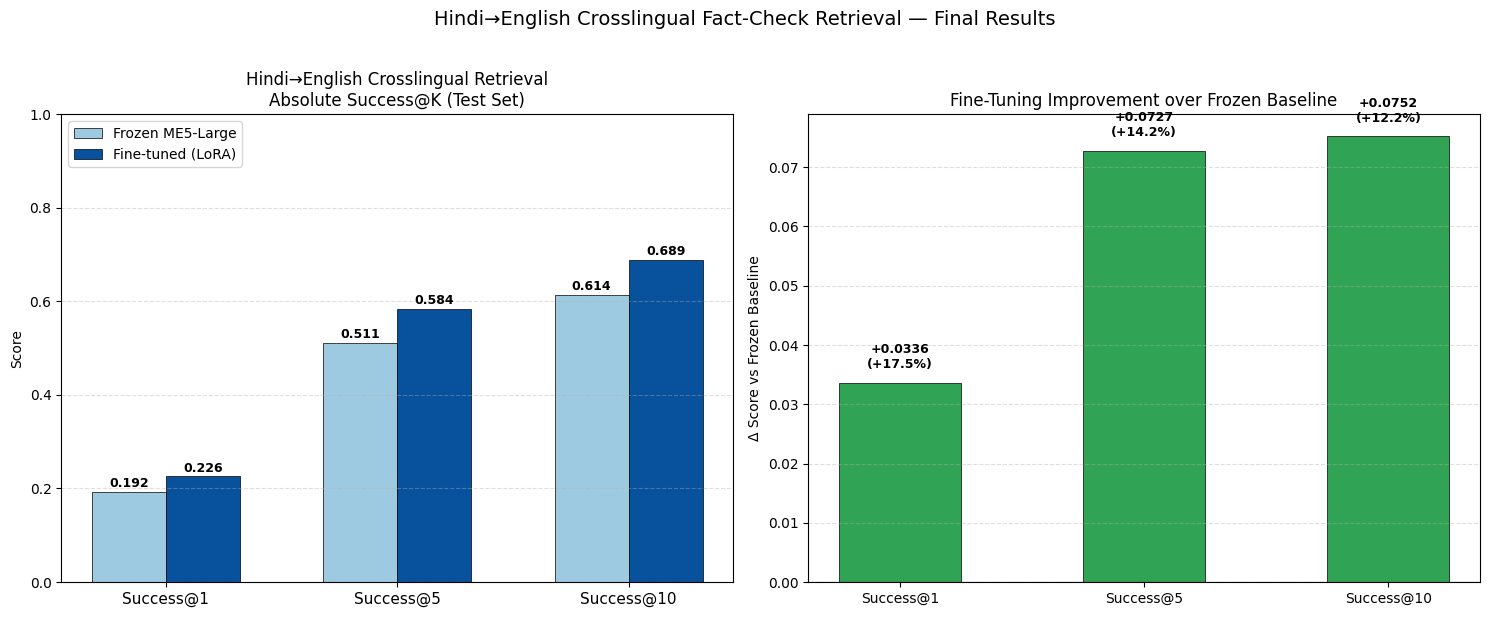

Saved comparison chart to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison/final_results_comparison_hin_eng.png


In [3]:
# ============================================================
# CELL 2: VISUALIZATION — FROZEN vs FINE-TUNED (all numbers hardcoded)
# ============================================================
results_frozen    = {'success@1': 0.1924, 'success@5': 0.5113, 'success@10': 0.6139}
results_finetuned = {'success@1': 0.2260, 'success@5': 0.5840, 'success@10': 0.6891}

metrics = ['success@1', 'success@5', 'success@10']
labels = ['Success@1', 'Success@5', 'Success@10']
x = np.arange(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: Absolute scores ---
ax = axes[0]
width = 0.32
frozen_vals = [results_frozen[m] for m in metrics]
ft_vals     = [results_finetuned[m] for m in metrics]

b1 = ax.bar(x - width/2, frozen_vals, width, label='Frozen ME5-Large',
            color='#9ECAE1', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned (LoRA)',
            color='#08519C', edgecolor='black', linewidth=0.5)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
ax.set_title('Hindi→English Crosslingual Retrieval\nAbsolute Success@K (Test Set)', fontsize=12)
ax.legend(loc='upper left'); ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Panel 2: Improvement over frozen baseline ---
ax2 = axes[1]
deltas = [results_finetuned[m] - results_frozen[m] for m in metrics]
pct = [(d / results_frozen[m]) * 100 for d, m in zip(deltas, metrics)]

bars = ax2.bar(x, deltas, 0.5, color='#31A354', edgecolor='black', linewidth=0.5)
for bar, d, p in zip(bars, deltas, pct):
    ax2.text(bar.get_x() + bar.get_width()/2, d + 0.002, f'{d:+.4f}\n({p:+.1f}%)',
              ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Δ Score vs Frozen Baseline')
ax2.set_title('Fine-Tuning Improvement over Frozen Baseline', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Hindi→English Crosslingual Fact-Check Retrieval — Final Results', fontsize=14, y=1.02)
plt.tight_layout()

chart_path = os.path.join(results_output_dir, 'final_results_comparison_hin_eng.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved comparison chart to: {chart_path}')

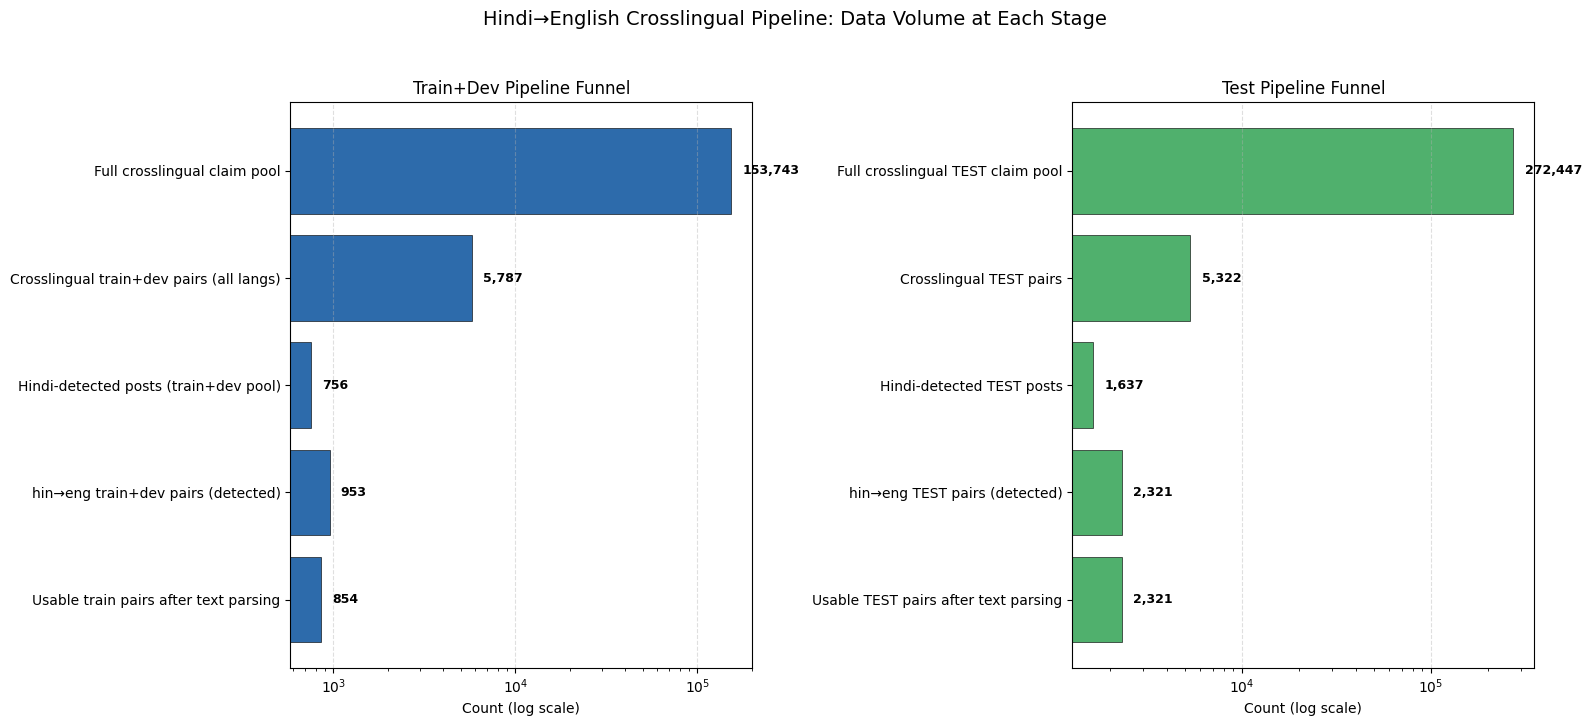

Saved pipeline funnel diagram to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison/pipeline_progression_funnel_hin_eng.png
Saved stage counts table (pipeline_stage_counts.csv)


In [4]:
# ============================================================
# CELL 3: PIPELINE PROGRESSION — DATA FUNNEL (all numbers hardcoded)
# ============================================================
train_dev_stages = [
    ('Full crosslingual claim pool',        153743),
    ('Crosslingual train+dev pairs (all langs)', 5787),
    ('Hindi-detected posts (train+dev pool)',    756),
    ('hin→eng train+dev pairs (detected)',       953),
    ('Usable train pairs after text parsing',    854),
]

test_stages = [
    ('Full crosslingual TEST claim pool',    272447),
    ('Crosslingual TEST pairs',               5322),
    ('Hindi-detected TEST posts',              1637),
    ('hin→eng TEST pairs (detected)',          2321),
    ('Usable TEST pairs after text parsing',   2321),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, stages, title, color in [
    (axes[0], train_dev_stages, 'Train+Dev Pipeline Funnel', '#08519C'),
    (axes[1], test_stages,      'Test Pipeline Funnel',      '#31A354'),
]:
    labels = [s[0] for s in stages]
    counts = [s[1] for s in stages]
    y_pos = range(len(stages))

    bars = ax.barh(y_pos, counts, color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_xscale('log')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Count (log scale)')
    ax.set_title(title, fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Hindi→English Crosslingual Pipeline: Data Volume at Each Stage', fontsize=14, y=1.03)
plt.tight_layout()

funnel_path = os.path.join(results_output_dir, 'pipeline_progression_funnel_hin_eng.png')
plt.savefig(funnel_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved pipeline funnel diagram to: {funnel_path}')

stage_df = pd.DataFrame({
    'Train+Dev Stage': [s[0] for s in train_dev_stages],
    'Train+Dev Count': [s[1] for s in train_dev_stages],
    'Test Stage': [s[0] for s in test_stages],
    'Test Count': [s[1] for s in test_stages],
})
stage_df.to_csv(os.path.join(results_output_dir, 'pipeline_stage_counts.csv'), index=False)
print('Saved stage counts table (pipeline_stage_counts.csv)')

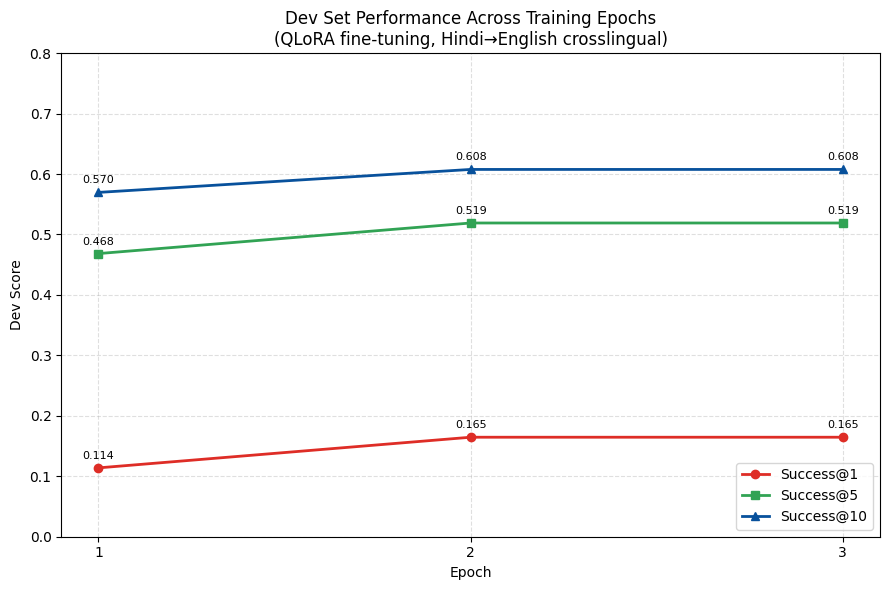

Saved training progression chart to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison/training_progression_by_epoch.png

Note: dev scores plateau between epoch 2 and 3 (identical values) — model converged early given the small train set (854 pairs).


In [5]:
# ============================================================
# CELL 4: TRAINING PROGRESSION — DEV SCORES ACROSS EPOCHS (hardcoded)
# ============================================================
epochs = [1, 2, 3]
epoch_s1  = [0.1139, 0.1646, 0.1646]
epoch_s5  = [0.4684, 0.5190, 0.5190]
epoch_s10 = [0.5696, 0.6076, 0.6076]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(epochs, epoch_s1, marker='o', label='Success@1', color='#DE2D26', linewidth=2)
ax.plot(epochs, epoch_s5, marker='s', label='Success@5', color='#31A354', linewidth=2)
ax.plot(epochs, epoch_s10, marker='^', label='Success@10', color='#08519C', linewidth=2)

for xs, ys in [(epochs, epoch_s1), (epochs, epoch_s5), (epochs, epoch_s10)]:
    for xi, yi in zip(xs, ys):
        ax.text(xi, yi + 0.015, f'{yi:.3f}', ha='center', fontsize=8)

ax.set_xticks(epochs)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dev Score')
ax.set_ylim(0, 0.8)
ax.set_title('Dev Set Performance Across Training Epochs\n(QLoRA fine-tuning, Hindi→English crosslingual)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
epoch_chart_path = os.path.join(results_output_dir, 'training_progression_by_epoch.png')
plt.savefig(epoch_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved training progression chart to: {epoch_chart_path}')
print('\nNote: dev scores plateau between epoch 2 and 3 (identical values) — '
      'model converged early given the small train set (854 pairs).')

In [6]:
# ============================================================
# CELL 5: SAVE RAW RESULTS DICT AS JSON (backup — regenerate CSV/MD later
# without re-deriving any numbers from scratch)
# ============================================================
import json
import os
from datetime import datetime

raw_results_backup = {
    'metadata': {
        'task': 'SemEval 2025 Task 7 — Crosslingual Fact-Check Retrieval',
        'language_pair': 'hin -> eng',
        'saved_at': datetime.now().isoformat(),
        'test_set_size': 2321,
        'test_target_paper_table4': 2337,
        'train_pairs_used': 854,
        'dev_pairs_used': 79,
        'model_base': 'intfloat/multilingual-e5-large',
        'finetune_method': 'QLoRA (r=8, alpha=16, target_modules=[query,key,value])',
        'epochs': 3,
        'ensemble_alpha_dev_tuned': 1.0,
        'ensemble_note': 'alpha=1.0 -> ensemble identical to fine-tuned-only; frozen model contributed nothing at any blend ratio on dev.'
    },
    'test_results': {
        'frozen_me5_large_fused_text': {
            'success@1': 0.1924,
            'success@5': 0.5113,
            'success@10': 0.6139
        },
        'finetuned_me5_large_lora_fused_text': {
            'success@1': 0.2260,
            'success@5': 0.5840,
            'success@10': 0.6891
        }
    },
    'dev_results_by_epoch': {
        'epoch_1': {'success@1': 0.1139, 'success@5': 0.4684, 'success@10': 0.5696},
        'epoch_2': {'success@1': 0.1646, 'success@5': 0.5190, 'success@10': 0.6076},
        'epoch_3': {'success@1': 0.1646, 'success@5': 0.5190, 'success@10': 0.6076}
    },
    'pipeline_stage_counts': {
        'train_dev': {
            'full_crosslingual_claim_pool': 153743,
            'crosslingual_train_dev_pairs_all_langs': 5787,
            'hindi_detected_posts': 756,
            'hin_eng_train_dev_pairs_detected': 953,
            'usable_train_pairs_after_text_parsing': 854
        },
        'test': {
            'full_crosslingual_test_claim_pool': 272447,
            'crosslingual_test_pairs': 5322,
            'hindi_detected_test_posts': 1637,
            'hin_eng_test_pairs_detected': 2321,
            'usable_test_pairs_after_text_parsing': 2321
        }
    }
}

OUTPUT_DIR = '/content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results'
results_output_dir = os.path.join(OUTPUT_DIR, 'final_comparison')
os.makedirs(results_output_dir, exist_ok=True)

backup_path = os.path.join(results_output_dir, 'raw_results_backup_hin_eng.json')
with open(backup_path, 'w') as f:
    json.dump(raw_results_backup, f, indent=2)

print(f'✅ Saved raw results backup to: {backup_path}')
print('\nReload later with:')
print("  with open(backup_path) as f: raw_results_backup = json.load(f)")

✅ Saved raw results backup to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison/raw_results_backup_hin_eng.json

Reload later with:
  with open(backup_path) as f: raw_results_backup = json.load(f)


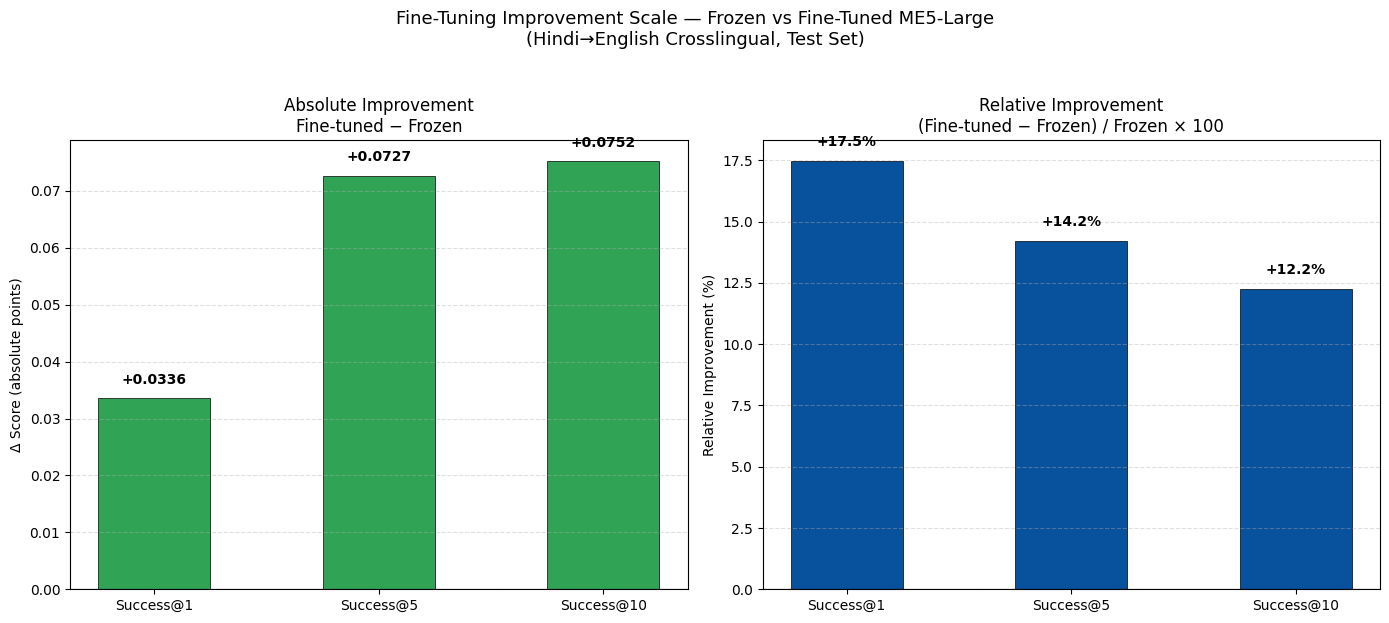

Saved improvement scale chart to: /content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results/final_comparison/improvement_scale_frozen_vs_finetuned.png

Summary:
  success@1: +0.0336 absolute (+17.5% relative)
  success@5: +0.0727 absolute (+14.2% relative)
  success@10: +0.0752 absolute (+12.2% relative)


In [7]:
# ============================================================
# CELL 6: IMPROVEMENT SCALE CHART — FROZEN vs FINE-TUNED ONLY
# (standalone delta chart, all numbers hardcoded)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

results_frozen    = {'success@1': 0.1924, 'success@5': 0.5113, 'success@10': 0.6139}
results_finetuned = {'success@1': 0.2260, 'success@5': 0.5840, 'success@10': 0.6891}

metrics = ['success@1', 'success@5', 'success@10']
labels = ['Success@1', 'Success@5', 'Success@10']
x = np.arange(3)

abs_deltas = [results_finetuned[m] - results_frozen[m] for m in metrics]
pct_deltas = [(d / results_frozen[m]) * 100 for d, m in zip(abs_deltas, metrics)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Absolute point improvement ---
ax = axes[0]
bars = ax.bar(x, abs_deltas, 0.5, color='#31A354', edgecolor='black', linewidth=0.5)
for bar, d in zip(bars, abs_deltas):
    ax.text(bar.get_x() + bar.get_width()/2, d + 0.002, f'+{d:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Δ Score (absolute points)')
ax.set_title('Absolute Improvement\nFine-tuned − Frozen', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Panel 2: Relative (%) improvement ---
ax2 = axes[1]
bars2 = ax2.bar(x, pct_deltas, 0.5, color='#08519C', edgecolor='black', linewidth=0.5)
for bar, p in zip(bars2, pct_deltas):
    ax2.text(bar.get_x() + bar.get_width()/2, p + 0.5, f'+{p:.1f}%',
              ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Relative Improvement (%)')
ax2.set_title('Relative Improvement\n(Fine-tuned − Frozen) / Frozen × 100', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Fine-Tuning Improvement Scale — Frozen vs Fine-Tuned ME5-Large\n(Hindi→English Crosslingual, Test Set)',
             fontsize=13, y=1.03)
plt.tight_layout()

OUTPUT_DIR = '/content/drive/MyDrive/semeval30august_hin_eng_crosslingual_results'
results_output_dir = os.path.join(OUTPUT_DIR, 'final_comparison')
os.makedirs(results_output_dir, exist_ok=True)

scale_chart_path = os.path.join(results_output_dir, 'improvement_scale_frozen_vs_finetuned.png')
plt.savefig(scale_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved improvement scale chart to: {scale_chart_path}')

print('\nSummary:')
for m, a, p in zip(metrics, abs_deltas, pct_deltas):
    print(f'  {m}: +{a:.4f} absolute ({p:+.1f}% relative)')